In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas
import random
import agama
import torch 
import numpy as np
from scipy import integrate
from astropy import units as u

from sbi.utils import BoxUniform
from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi
from sbi.utils import likelihood_nn

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import pickle
import matplotlib.pyplot as plt
from galaxy_generation import generate_galaxy_multiple
# from python_scripts.prior_generation import generate_prior
import corner

agama.setRandomSeed(13)
torch.manual_seed(13)
np.random.seed(13)
random.seed(13)

torch.set_num_threads(4)

In [8]:
# Galaxy
log_p_0 = 7
log_r_s = 0
gamma = 1
r_star_div_r_s = 0.2
r_star = r_star_div_r_s * 10 ** log_r_s

galaxy = np.expand_dims(np.array([log_p_0, log_r_s, gamma, r_star_div_r_s]), axis=0).astype(np.float32)

## Generate

In [9]:
df = generate_galaxy_multiple(torch.tensor(galaxy), [100], 1)

pd.DataFrame(df).to_csv("mass_density_x_cusp_model_9_test.csv", header=None, index=None)

## Contour

In [32]:
with open("inference_model_9_cusp_v2.pkl", "rb") as file:
    inference = pickle.load(file)

In [33]:
df = inference._neural_net.sample(100_000, context=galaxy).squeeze().detach().numpy()

In [34]:
pd.DataFrame(df).to_csv("contour_samples_model_9_cusp_v2.csv", header=None, index=None)

## Model evaluation

In [33]:
a = np.random.poisson(100, 1000)
while a.sum() != 100_000:
    a = np.random.poisson(100, 1000)
    

In [37]:
pd.DataFrame(a).to_csv("theta_test.csv", header=None, index=None)

In [2]:
def evaluate_model(theta, medians):
    """
    Evaluates model for theta with galaxies with same number of star
    """
    
    for i in range(4):
        mse = mean_squared_error(theta[:,i], medians[:,i])
        r2 = r2_score(theta[:,i], medians[:,i])
        print(f"MSE for {i}th entry is {mse}")
        print(f"R^2 for {i}th entry is {r2}")
        print()

In [3]:
with open("./samples_model_9_core.pkl", "rb") as file:
    post = pickle.load(file)
    
medians = np.zeros((1000,4))
for i, th in enumerate(post):
    medians[i,:] = np.median(th, axis=0)
    



In [6]:
test_theta = np.repeat(galaxy, 1000, axis=0)

In [7]:
evaluate_model(test_theta, medians)


MSE for 0th entry is 0.408828397515545
R^2 for 0th entry is 0.0

MSE for 1th entry is 0.09608580007559996
R^2 for 1th entry is 0.0

MSE for 2th entry is 0.45277433434423664
R^2 for 2th entry is 0.0

MSE for 3th entry is 0.051804671703032
R^2 for 3th entry is -58326875044455.445



In [8]:
post

[array([[ 7.384463  , -0.17222822,  0.84669375,  0.3261441 ],
        [ 7.4634767 , -0.18362492,  0.6198263 ,  0.3691987 ],
        [ 7.452888  , -0.21176344,  0.68182206,  0.37056762],
        ...,
        [ 7.1979184 , -0.14142388,  0.74989533,  0.3506587 ],
        [ 7.333765  , -0.1495527 ,  0.751287  ,  0.3448071 ],
        [ 7.4082913 , -0.17118174,  0.75979984,  0.32437518]],
       dtype=float32),
 array([[ 7.784586  , -0.34699506,  0.45581937,  0.40367535],
        [ 7.778903  , -0.34010446,  0.4853394 ,  0.40151316],
        [ 7.7725325 , -0.3611027 ,  0.52226233,  0.42557576],
        ...,
        [ 7.754073  , -0.35392058,  0.4094746 ,  0.45728242],
        [ 7.735959  , -0.3205377 ,  0.4641385 ,  0.42717314],
        [ 7.739293  , -0.31937104,  0.43728042,  0.4324999 ]],
       dtype=float32),
 array([[ 7.6133776 , -0.35833824,  0.7552552 ,  0.4469148 ],
        [ 7.6270733 , -0.37350523,  0.7527039 ,  0.48825127],
        [ 7.7055187 , -0.39072937,  0.6851046 ,  0.4569056

## Corner plot

In [16]:
galaxy[0].shape

(4,)

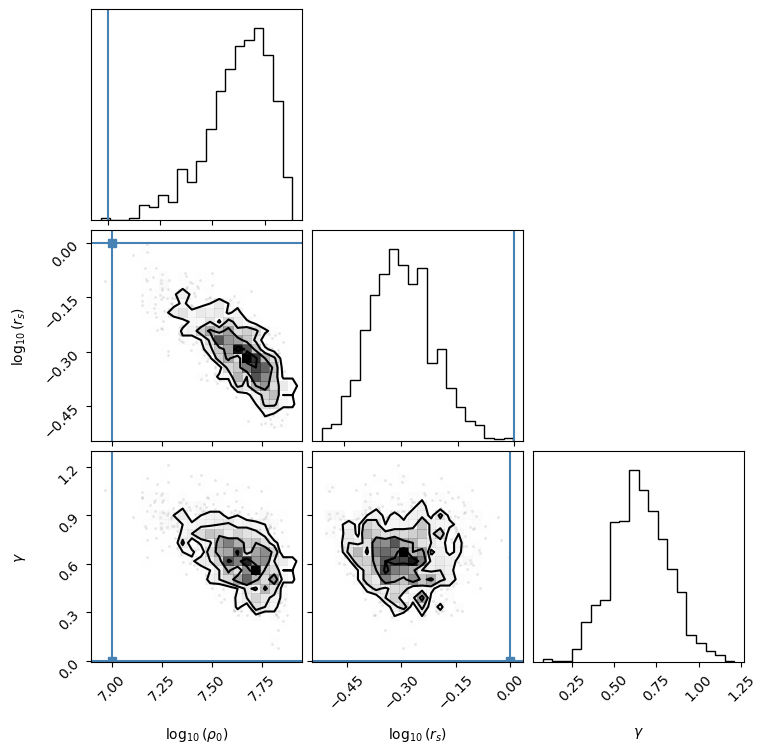

In [18]:
fig = corner.corner(
    medians[:, :3],
    truths=galaxy[0][:3],
    labels=[r"$\log_{10}(\rho_0)$", r"$\log_{10}(r_s)$", r"$\gamma$"],
    fig=plt.figure(figsize=(8, 8)),
)

## Prepping for Mass Density

In [32]:
with open("samples_model_9_cusp.pkl", "rb") as file:
    post = pickle.load(file)

In [16]:
df = np.array(pd.read_csv("theta_test.csv", header=None))

In [33]:
df_x = np.array(pd.read_csv("x_test_cusp.csv", header=None))

In [34]:
df_x.shape

(100000, 6)

In [35]:
pd.DataFrame(df_x[df.cumsum()[16]:df.cumsum()[17]]).to_csv("mass_density_x_cusp_model_9.csv", header=None, index=None)

In [36]:
pd.DataFrame(post[17]).to_csv("mass_density_samples_cusp_model_9.csv", header=None, index=None)